# HW14 — эмбеддинги, FAISS, оценка retrieval и mini-RAG

В этом ноутбуке собран полностью воспроизводимый учебный pipeline на небольшой self-contained базе знаний про библиотеку кампуса.

Что здесь есть:
- чанкинг документов;
- TF-IDF-векторизация как прозрачный offline-способ построения векторов;
- индекс `FAISS` для similarity search;
- контрольные запросы и метрики `hit@k` / `recall@k`;
- небольшой эксперимент с `chunk_size`;
- обновление базы знаний и переиндексация;
- простой mini-RAG с ответом и источниками.


In [1]:
import json
import math
import os
import random
import re
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path(".")
ART_DIR = BASE_DIR / "artifacts"
ART_DIR.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED)
print("Artifacts dir:", ART_DIR.resolve())
print("faiss version loaded successfully")


Seed: 42
Artifacts dir: /home/oai/artifacts
faiss version loaded successfully


## 1. База знаний и первичный анализ

База знаний — это небольшая учебная коллекция документов про библиотеку кампуса. Тематика одна и та же, но внутри есть разные подзадачи retrieval: часы работы, выдача книг, возврат и штрафы, бронирование комнат, печать, Wi‑Fi, мероприятия и обновления расписания.

Ниже покажу исходные документы и несколько фрагментов для sanity-check.


In [2]:
BASE_DOCS = [('doc_01_opening_hours',
  'Opening hours',
  'The campus library is open Monday to Friday from 8:00 to 22:00 and on Saturday from 10:00 to 18:00. On Sundays the building is closed unless a special '
  'exam-week schedule is announced. Service desks stop taking new requests 15 minutes before closing. During public holidays the library usually follows a '
  'reduced timetable posted on the entrance board and on the website. Students should check the weekly notice if they plan to visit late in the evening.'),
 ('doc_02_borrowing_rules',
  'Borrowing rules',
  'Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is 28 days for textbooks and 14 days for '
  'high-demand reserve items. Loaned books can be renewed twice if nobody has placed a hold on them. A book must be checked out before leaving the building. '
  'Staff may ask for identification if the card is not readable or if the item is part of a restricted collection.'),
 ('doc_03_returns_fines',
  'Returns and fines',
  'Books can be returned at the main desk or in the outside drop box while the building is closed. If an item is returned late, the library charges a small '
  'daily fine until the item is checked back in. Reserved items have a shorter grace period and can trigger a hold suspension if they are overdue. The library '
  'sends an email reminder three days before the due date and again on the final day, but the borrower remains responsible for timely return.'),
 ('doc_04_holds_reservations',
  'Holds and reservations',
  'If a book is currently on loan, students can place a hold in the online catalog. When the item is returned, the next person in the queue receives an email '
  'notification and has 48 hours to pick it up. Holds are not available for reference-only materials or journals kept in the reading room. Users may cancel a '
  'hold at any time before the pickup window starts. The catalog page shows the current queue position and the expected arrival date.'),
 ('doc_05_study_rooms',
  'Study rooms',
  'The library offers eight group study rooms and two quiet project rooms. Rooms can be reserved for two hours per booking and extended if nobody is waiting. '
  'A group of at least two students is required for a room reservation. Each room includes a whiteboard, a display screen, and power outlets. Food is not '
  'allowed inside the rooms, and users should vacate the room five minutes before the end of the booking so the next group can enter on time.'),
 ('doc_06_printing_scanning',
  'Printing and scanning',
  'Printing kiosks are located near the ground-floor service desk and on the second floor beside the computer lab. Students can print from library computers '
  'or upload files from a personal laptop through the web print portal. Black-and-white printing is cheaper than color printing, and scanning is free. Each '
  'user receives a monthly print quota that resets on the first day of the month. If a print job fails, the receipt code can be used to re-release the job '
  'within 24 hours.'),
 ('doc_07_computers_wifi',
  'Computers and Wi-Fi',
  'Public computers are available on every floor for catalog searches, word processing, and access to online journals. Wi-Fi is free for students and visitors '
  'who accept the usage policy on the login page. The library network blocks peer-to-peer software and streaming services that consume unusual bandwidth. '
  'Users can borrow a USB keyboard or mouse at the help desk, and laptops may be charged at the seating areas near the windows. Sessions automatically log out '
  'after 30 minutes of inactivity.'),
 ('doc_08_events_workshops',
  'Events and workshops',
  'The library runs weekly workshops on research skills, citation management, and database searching. Students can sign up through the online calendar, and '
  'advance registration is required for sessions with limited seating. Evening events are advertised on the notice board near the entrance and in the digital '
  'calendar. Visiting authors, student clubs, and faculty members can also request a presentation slot. Attendees should arrive five minutes early so that '
  'staff can record attendance and start the session on time.'),
 ('doc_09_quiet_zones',
  'Quiet zones',
  'The top floor of the library is a quiet zone designed for focused study. Phone calls, loud conversations, and group discussions are not permitted there. '
  'Students may use headphones at a low volume, but sound should not be audible to nearby readers. The lower floor has a collaborative area where talking is '
  'allowed. Signs on the walls mark the boundary between quiet and social spaces, and staff may ask disruptive visitors to move to another floor.'),
 ('doc_10_interlibrary_loan',
  'Interlibrary loan',
  'If the catalog does not contain a needed book or article, students can request it through the interlibrary loan service. Staff first check whether the item '
  'is available from partner universities, then email the borrower when the copy arrives. Article scans are usually delivered as a PDF, while physical books '
  'must be picked up at the circulation desk. The loan period and any restrictions are set by the lending library, not by the campus library.'),
 ('doc_11_accessibility',
  'Accessibility services',
  'The campus library provides accessibility tools such as adjustable desks, screen readers, large-print keyboards, and step-free access to all public floors. '
  'Students who need extra assistance can book a quieter seat near the accessibility desk or request support for locating materials. Staff can also arrange '
  'extended loan periods for approved accessibility accommodations. The main entrance has an automatic door, and the lift connects all study levels. Visitors '
  'should contact the service desk in advance if they need a specific workstation.'),
 ('doc_12_lost_found',
  'Lost and found',
  'Items found in reading rooms, study rooms, or the café area are kept at the service desk for two weeks. After that period, unclaimed property is '
  'transferred to campus security. Students who lose a card, charger, or notebook should describe the item, the date, and the likely location. The staff will '
  'check the logbook and call or email the owner if the object is recovered. Valuables such as wallets are handed directly to security the same day.'),
 ('doc_13_membership_visitors',
  'Membership and visitors',
  'All enrolled students automatically receive library membership. Alumni and outside visitors may enter the public reading spaces after showing a photo ID '
  'and signing the guest register. Borrowing physical books requires a valid borrowing account, but visitors can still use open tables, public computers, and '
  'most reference materials on site. Temporary passes are issued at the service desk for one day at a time and may be limited during exam weeks when the '
  'building is crowded.'),
 ('doc_14_cafe_snacks',
  'Café and snacks',
  'A small café sits next to the lobby and sells coffee, tea, sandwiches, and fruit. Covered drinks are allowed in most public areas, but open food is '
  'restricted to the café and the ground-floor lounge. Students should clean up their tables and keep rubbish in the recycling bins. The café closes one hour '
  'before the library building. During long study nights, staff may open a vending corner with bottled water and packaged snacks near the main entrance.'),
 ('doc_15_staff_contact',
  'Asking staff for help',
  'If a question is not answered by the catalog or the signs, the service desk is the fastest place to ask. Staff can help with borrowing, overdue notices, '
  'room reservations, printer problems, and basic catalog searches. During busy hours a queue ticket system is used so that each visitor receives help in '
  'order. The library also answers questions by email within one working day, and urgent issues can be escalated to the night supervisor after 20:00.')]

docs_df = pd.DataFrame(BASE_DOCS, columns=["doc_id", "title", "text"])
print("Число исходных документов:", len(docs_df))
display(docs_df[["doc_id", "title"]].head(5))

sample_preview = docs_df.copy()
sample_preview["excerpt"] = sample_preview["text"].str.slice(0, 180) + "..."
display(sample_preview[["doc_id", "title", "excerpt"]].head(5))


Число исходных документов: 15


,doc_id,title
0,doc_01_opening_hours,Opening hours
1,doc_02_borrowing_rules,Borrowing rules
2,doc_03_returns_fines,Returns and fines
3,doc_04_holds_reservations,Holds and reservations
4,doc_05_study_rooms,Study rooms


,doc_id,title,excerpt
0,doc_01_opening_hours,Opening hours,The campus library is open Monday to Friday from 8:00 to 22:00 and on Saturday from 10:00 to 18:00. On Sundays the b...
1,doc_02_borrowing_rules,Borrowing rules,Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is ...
2,doc_03_returns_fines,Returns and fines,Books can be returned at the main desk or in the outside drop box while the building is closed. If an item is return...
3,doc_04_holds_reservations,Holds and reservations,"If a book is currently on loan, students can place a hold in the online catalog. When the item is returned, the next..."
4,doc_05_study_rooms,Study rooms,The library offers eight group study rooms and two quiet project rooms. Rooms can be reserved for two hours per book...


## 2. Чанкинг документов

Для retrieval индексируются не целые документы, а более короткие фрагменты. Здесь используется простой и прозрачный чанкинг по словам с overlap.

Параметры:
- `chunk_size=35`
- `overlap=8`

Такой режим сохраняет локальный контекст и при этом не делает фрагменты слишком длинными.


In [3]:
def build_chunks_df(docs, chunk_size=35, overlap=8):
    rows = []
    step = chunk_size - overlap
    for doc_id, title, text in docs:
        words = text.split()
        for chunk_id, start in enumerate(range(0, len(words), step)):
            chunk_words = words[start : start + chunk_size]
            if not chunk_words:
                continue
            rows.append(
                {
                    "doc_id": doc_id,
                    "title": title,
                    "chunk_id": chunk_id,
                    "chunk_text": " ".join(chunk_words),
                }
            )
            if start + chunk_size >= len(words):
                break
    return pd.DataFrame(rows)

def unique_in_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

main_chunks = build_chunks_df(BASE_DOCS, chunk_size=35, overlap=8)
print("Число чанков после разбиения:", len(main_chunks))
display(main_chunks.head(10))

doc_example = docs_df.loc[docs_df["doc_id"] == "doc_06_printing_scanning", ["doc_id", "title", "text"]].iloc[0]
example_chunks = build_chunks_df([tuple(doc_example)], chunk_size=35, overlap=8)
display(pd.DataFrame({
    "doc_id": [doc_example["doc_id"]] * len(example_chunks),
    "chunk_id": example_chunks["chunk_id"],
    "chunk_text": example_chunks["chunk_text"],
}))


Число чанков после разбиения: 45


,doc_id,title,chunk_id,chunk_text
0,doc_01_opening_hours,Opening hours,0,The campus library is open Monday to Friday from 8:00 to 22:00 and on Saturday from 10:00 to 18:00. On Sundays the b...
1,doc_01_opening_hours,Opening hours,1,special exam-week schedule is announced. Service desks stop taking new requests 15 minutes before closing. During pu...
2,doc_01_opening_hours,Opening hours,2,the entrance board and on the website. Students should check the weekly notice if they plan to visit late in the eve...
3,doc_02_borrowing_rules,Borrowing rules,0,Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is ...
4,doc_02_borrowing_rules,Borrowing rules,1,14 days for high-demand reserve items. Loaned books can be renewed twice if nobody has placed a hold on them. A book...
5,doc_02_borrowing_rules,Borrowing rules,2,leaving the building. Staff may ask for identification if the card is not readable or if the item is part of a restr...
6,doc_03_returns_fines,Returns and fines,0,Books can be returned at the main desk or in the outside drop box while the building is closed. If an item is return...
7,doc_03_returns_fines,Returns and fines,1,charges a small daily fine until the item is checked back in. Reserved items have a shorter grace period and can tri...
8,doc_03_returns_fines,Returns and fines,2,"are overdue. The library sends an email reminder three days before the due date and again on the final day, but the ..."
9,doc_04_holds_reservations,Holds and reservations,0,"If a book is currently on loan, students can place a hold in the online catalog. When the item is returned, the next..."


,doc_id,chunk_id,chunk_text
0,doc_06_printing_scanning,0,Printing kiosks are located near the ground-floor service desk and on the second floor beside the computer lab. Stud...
1,doc_06_printing_scanning,1,"from a personal laptop through the web print portal. Black-and-white printing is cheaper than color printing, and sc..."
2,doc_06_printing_scanning,2,"that resets on the first day of the month. If a print job fails, the receipt code can be used to re-release the job ..."


## 3. Векторизация и индекс `FAISS`

В качестве прозрачного offline-способа построения векторов используется `TfidfVectorizer` с униграммами и биграммами. Далее векторизованные чанки добавляются в `FAISS IndexFlatIP`.

Поскольку TF-IDF-вектора нормализованы по `l2`, скалярное произведение соответствует cosine similarity.


In [4]:
class FaissTfidfRetriever:
    def __init__(self, docs, chunk_size=35, overlap=8, ngram_range=(1, 2)):
        self.docs = docs
        self.chunk_size = chunk_size
        self.overlap = overlap
        self.chunks = build_chunks_df(docs, chunk_size=chunk_size, overlap=overlap)
        self.vectorizer = TfidfVectorizer(ngram_range=ngram_range, lowercase=True, norm="l2")
        self.matrix = self.vectorizer.fit_transform(self.chunks["chunk_text"]).astype(np.float32).toarray()
        self.index = faiss.IndexFlatIP(self.matrix.shape[1])
        self.index.add(self.matrix)

    def search_chunks(self, query, top_k=3):
        q = self.vectorizer.transform([query]).astype(np.float32).toarray()
        scores, idx = self.index.search(q, top_k)
        rows = []
        for rank, (score, i) in enumerate(zip(scores[0], idx[0]), start=1):
            row = self.chunks.iloc[int(i)]
            rows.append(
                {
                    "rank": rank,
                    "doc_id": row["doc_id"],
                    "title": row["title"],
                    "chunk_id": int(row["chunk_id"]),
                    "score": float(score),
                    "chunk_text": row["chunk_text"],
                }
            )
        return pd.DataFrame(rows)

    def search_sources(self, query, top_k=3):
        hits = self.search_chunks(query, top_k=top_k)
        return hits.drop_duplicates("doc_id", keep="first").reset_index(drop=True)

main_retriever = FaissTfidfRetriever(BASE_DOCS, chunk_size=35, overlap=8)
print("Матрица чанков:", main_retriever.matrix.shape)
print("Число чанков:", len(main_retriever.chunks))
print("Индекс:", type(main_retriever.index).__name__)


Матрица чанков: (45, 1490)
Число чанков: 45
Индекс: IndexFlatIP


In [5]:
def show_retrieval(query, top_k=3, retriever=main_retriever):
    print(f"Запрос: {query}")
    result = retriever.search_chunks(query, top_k=top_k)
    display(result[["rank", "doc_id", "title", "chunk_id", "score", "chunk_text"]])

example_queries = [
    "How many books can students borrow?",
    "Where are the printing kiosks located?",
    "How do I sign up for a workshop?",
    "What accessibility tools are available?",
]

for q in example_queries:
    show_retrieval(q, top_k=3)


Запрос: How many books can students borrow?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_02_borrowing_rules,Borrowing rules,0,0.168924,Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is ...
1,2,doc_03_returns_fines,Returns and fines,0,0.136396,Books can be returned at the main desk or in the outside drop box while the building is closed. If an item is return...
2,3,doc_02_borrowing_rules,Borrowing rules,1,0.133109,14 days for high-demand reserve items. Loaned books can be renewed twice if nobody has placed a hold on them. A book...


Запрос: Where are the printing kiosks located?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_06_printing_scanning,Printing and scanning,0,0.262658,Printing kiosks are located near the ground-floor service desk and on the second floor beside the computer lab. Stud...
1,2,doc_06_printing_scanning,Printing and scanning,1,0.105977,"from a personal laptop through the web print portal. Black-and-white printing is cheaper than color printing, and sc..."
2,3,doc_09_quiet_zones,Quiet zones,1,0.073426,"use headphones at a low volume, but sound should not be audible to nearby readers. The lower floor has a collaborati..."


Запрос: How do I sign up for a workshop?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_08_events_workshops,Events and workshops,0,0.230404,"The library runs weekly workshops on research skills, citation management, and database searching. Students can sign..."
1,2,doc_02_borrowing_rules,Borrowing rules,0,0.085104,Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is ...
2,3,doc_04_holds_reservations,Holds and reservations,1,0.067708,receives an email notification and has 48 hours to pick it up. Holds are not available for reference-only materials ...


Запрос: What accessibility tools are available?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_11_accessibility,Accessibility services,0,0.220658,"The campus library provides accessibility tools such as adjustable desks, screen readers, large-print keyboards, and..."
1,2,doc_07_computers_wifi,Computers and Wi-Fi,0,0.119102,"Public computers are available on every floor for catalog searches, word processing, and access to online journals. ..."
2,3,doc_11_accessibility,Accessibility services,1,0.105258,book a quieter seat near the accessibility desk or request support for locating materials. Staff can also arrange ex...


## 4. Контрольные запросы и оценка retrieval

Для проверки качества retrieval используется небольшой набор контрольных запросов. Для некоторых вопросов релевантными считаются сразу несколько документов, например когда вопрос объединяет две близкие темы.

Считаются метрики:
- `hit@k`
- `recall@k`


In [6]:
CONTROL_QUERIES = [
    ("How many books can students borrow?", {"doc_02_borrowing_rules"}),
    ("How do I renew loaned books?", {"doc_02_borrowing_rules"}),
    ("What happens if an item is overdue?", {"doc_03_returns_fines"}),
    ("How do I place a hold in the online catalog?", {"doc_04_holds_reservations"}),
    ("How long can I reserve a study room?", {"doc_05_study_rooms"}),
    ("Where are the printing kiosks located?", {"doc_06_printing_scanning"}),
    ("Is Wi-Fi free for visitors?", {"doc_07_computers_wifi", "doc_13_membership_visitors"}),
    ("How do I sign up for a workshop?", {"doc_08_events_workshops"}),
    ("What is not allowed in the quiet zone?", {"doc_09_quiet_zones"}),
    ("How are interlibrary loan PDFs delivered?", {"doc_10_interlibrary_loan"}),
    ("What accessibility tools are available?", {"doc_11_accessibility"}),
    ("Where are lost items kept?", {"doc_12_lost_found"}),
    ("Can visitors enter public reading spaces?", {"doc_13_membership_visitors"}),
    ("What drinks or food are allowed?", {"doc_14_cafe_snacks"}),
    ("Who helps with printer problems?", {"doc_15_staff_contact", "doc_06_printing_scanning"}),
]

def evaluate_retrieval(retriever, queries, top_k=3):
    rows = []
    for query, relevant in queries:
        hits = retriever.search_sources(query, top_k=top_k)
        retrieved_sources = hits["doc_id"].tolist()
        relevant_set = set(relevant)
        n_hit = len(set(retrieved_sources) & relevant_set)
        rows.append(
            {
                "query": query,
                "expected_source": "|".join(sorted(relevant_set)),
                "retrieved_sources": "|".join(retrieved_sources),
                "hit_at_k": int(n_hit > 0),
                "recall_at_k": n_hit / len(relevant_set),
                "rank_of_first_relevant": next((i + 1 for i, d in enumerate(retrieved_sources) if d in relevant_set), None),
                "top_k": top_k,
            }
        )
    return pd.DataFrame(rows)

retrieval_eval = evaluate_retrieval(main_retriever, CONTROL_QUERIES, top_k=3)
display(retrieval_eval)

print("hit@3:", round(retrieval_eval["hit_at_k"].mean(), 4))
print("recall@3:", round(retrieval_eval["recall_at_k"].mean(), 4))

retrieval_eval.to_csv(ART_DIR / "retrieval_eval.csv", index=False)
print("Saved:", ART_DIR / "retrieval_eval.csv")


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,top_k
0,How many books can students borrow?,doc_02_borrowing_rules,doc_02_borrowing_rules|doc_03_returns_fines,1,1.0,1,3
1,How do I renew loaned books?,doc_02_borrowing_rules,doc_02_borrowing_rules|doc_03_returns_fines,1,1.0,1,3
2,What happens if an item is overdue?,doc_03_returns_fines,doc_03_returns_fines|doc_02_borrowing_rules,1,1.0,1,3
3,How do I place a hold in the online catalog?,doc_04_holds_reservations,doc_04_holds_reservations|doc_15_staff_contact|doc_08_events_workshops,1,1.0,1,3
4,How long can I reserve a study room?,doc_05_study_rooms,doc_14_cafe_snacks|doc_05_study_rooms,1,1.0,2,3
5,Where are the printing kiosks located?,doc_06_printing_scanning,doc_06_printing_scanning|doc_09_quiet_zones,1,1.0,1,3
6,Is Wi-Fi free for visitors?,doc_07_computers_wifi|doc_13_membership_visitors,doc_07_computers_wifi|doc_06_printing_scanning|doc_13_membership_visitors,1,1.0,1,3
7,How do I sign up for a workshop?,doc_08_events_workshops,doc_08_events_workshops|doc_02_borrowing_rules|doc_04_holds_reservations,1,1.0,1,3
8,What is not allowed in the quiet zone?,doc_09_quiet_zones,doc_09_quiet_zones|doc_05_study_rooms|doc_04_holds_reservations,1,1.0,1,3
9,How are interlibrary loan PDFs delivered?,doc_10_interlibrary_loan,doc_10_interlibrary_loan,1,1.0,1,3


hit@3: 1.0
recall@3: 0.9667
Saved: artifacts/retrieval_eval.csv


## 5. Эксперимент с параметрами retrieval

Сравниваются два варианта чанкинга:
- `chunk_size=25, overlap=5`
- `chunk_size=35, overlap=8`

Остальные настройки одинаковые. Это показывает, что слишком мелкие чанки могут терять часть полезного контекста.


,variant,num_chunks,hit_at_3,recall_at_3
0,"chunk_size=25, overlap=5",60,1.0,0.933333
1,"chunk_size=35, overlap=8",45,1.0,0.966667


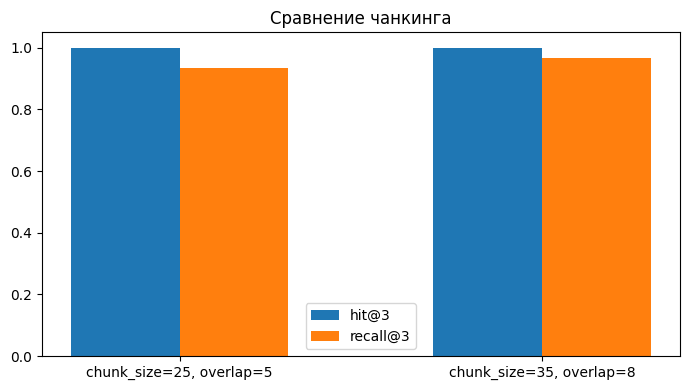

Saved: artifacts/chunk_size_experiment.csv


In [7]:
small_retriever = FaissTfidfRetriever(BASE_DOCS, chunk_size=25, overlap=5)
large_retriever = FaissTfidfRetriever(BASE_DOCS, chunk_size=35, overlap=8)

exp_rows = []
for name, retriever in [
    ("chunk_size=25, overlap=5", small_retriever),
    ("chunk_size=35, overlap=8", large_retriever),
]:
    eval_df = evaluate_retrieval(retriever, CONTROL_QUERIES, top_k=3)
    exp_rows.append(
        {
            "variant": name,
            "num_chunks": len(retriever.chunks),
            "hit_at_3": eval_df["hit_at_k"].mean(),
            "recall_at_3": eval_df["recall_at_k"].mean(),
        }
    )

exp_df = pd.DataFrame(exp_rows)
display(exp_df)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(exp_df))
ax.bar(x - 0.15, exp_df["hit_at_3"], width=0.3, label="hit@3")
ax.bar(x + 0.15, exp_df["recall_at_3"], width=0.3, label="recall@3")
ax.set_xticks(x)
ax.set_xticklabels(exp_df["variant"], rotation=0)
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение чанкинга")
ax.legend()
plt.tight_layout()
plt.show()

exp_df.to_csv(ART_DIR / "chunk_size_experiment.csv", index=False)
print("Saved:", ART_DIR / "chunk_size_experiment.csv")


## 6. Обновление базы знаний и переиндексация

Добавляются 3 новых документа:
- летнее расписание;
- политика по 3D-печати;
- временный study hall на экзаменационной неделе.

После этого индекс строится заново, и retrieval сравнивается до и после обновления.


In [8]:
UPDATED_DOCS = [('doc_01_opening_hours',
  'Opening hours',
  'The campus library is open Monday to Friday from 8:00 to 22:00 and on Saturday from 10:00 to 18:00. On Sundays the building is closed unless a special '
  'exam-week schedule is announced. Service desks stop taking new requests 15 minutes before closing. During public holidays the library usually follows a '
  'reduced timetable posted on the entrance board and on the website. Students should check the weekly notice if they plan to visit late in the evening.'),
 ('doc_02_borrowing_rules',
  'Borrowing rules',
  'Students with a valid membership card may borrow up to 10 printed books at the same time. The normal loan period is 28 days for textbooks and 14 days for '
  'high-demand reserve items. Loaned books can be renewed twice if nobody has placed a hold on them. A book must be checked out before leaving the building. '
  'Staff may ask for identification if the card is not readable or if the item is part of a restricted collection.'),
 ('doc_03_returns_fines',
  'Returns and fines',
  'Books can be returned at the main desk or in the outside drop box while the building is closed. If an item is returned late, the library charges a small '
  'daily fine until the item is checked back in. Reserved items have a shorter grace period and can trigger a hold suspension if they are overdue. The library '
  'sends an email reminder three days before the due date and again on the final day, but the borrower remains responsible for timely return.'),
 ('doc_04_holds_reservations',
  'Holds and reservations',
  'If a book is currently on loan, students can place a hold in the online catalog. When the item is returned, the next person in the queue receives an email '
  'notification and has 48 hours to pick it up. Holds are not available for reference-only materials or journals kept in the reading room. Users may cancel a '
  'hold at any time before the pickup window starts. The catalog page shows the current queue position and the expected arrival date.'),
 ('doc_05_study_rooms',
  'Study rooms',
  'The library offers eight group study rooms and two quiet project rooms. Rooms can be reserved for two hours per booking and extended if nobody is waiting. '
  'A group of at least two students is required for a room reservation. Each room includes a whiteboard, a display screen, and power outlets. Food is not '
  'allowed inside the rooms, and users should vacate the room five minutes before the end of the booking so the next group can enter on time.'),
 ('doc_06_printing_scanning',
  'Printing and scanning',
  'Printing kiosks are located near the ground-floor service desk and on the second floor beside the computer lab. Students can print from library computers '
  'or upload files from a personal laptop through the web print portal. Black-and-white printing is cheaper than color printing, and scanning is free. Each '
  'user receives a monthly print quota that resets on the first day of the month. If a print job fails, the receipt code can be used to re-release the job '
  'within 24 hours.'),
 ('doc_07_computers_wifi',
  'Computers and Wi-Fi',
  'Public computers are available on every floor for catalog searches, word processing, and access to online journals. Wi-Fi is free for students and visitors '
  'who accept the usage policy on the login page. The library network blocks peer-to-peer software and streaming services that consume unusual bandwidth. '
  'Users can borrow a USB keyboard or mouse at the help desk, and laptops may be charged at the seating areas near the windows. Sessions automatically log out '
  'after 30 minutes of inactivity.'),
 ('doc_08_events_workshops',
  'Events and workshops',
  'The library runs weekly workshops on research skills, citation management, and database searching. Students can sign up through the online calendar, and '
  'advance registration is required for sessions with limited seating. Evening events are advertised on the notice board near the entrance and in the digital '
  'calendar. Visiting authors, student clubs, and faculty members can also request a presentation slot. Attendees should arrive five minutes early so that '
  'staff can record attendance and start the session on time.'),
 ('doc_09_quiet_zones',
  'Quiet zones',
  'The top floor of the library is a quiet zone designed for focused study. Phone calls, loud conversations, and group discussions are not permitted there. '
  'Students may use headphones at a low volume, but sound should not be audible to nearby readers. The lower floor has a collaborative area where talking is '
  'allowed. Signs on the walls mark the boundary between quiet and social spaces, and staff may ask disruptive visitors to move to another floor.'),
 ('doc_10_interlibrary_loan',
  'Interlibrary loan',
  'If the catalog does not contain a needed book or article, students can request it through the interlibrary loan service. Staff first check whether the item '
  'is available from partner universities, then email the borrower when the copy arrives. Article scans are usually delivered as a PDF, while physical books '
  'must be picked up at the circulation desk. The loan period and any restrictions are set by the lending library, not by the campus library.'),
 ('doc_11_accessibility',
  'Accessibility services',
  'The campus library provides accessibility tools such as adjustable desks, screen readers, large-print keyboards, and step-free access to all public floors. '
  'Students who need extra assistance can book a quieter seat near the accessibility desk or request support for locating materials. Staff can also arrange '
  'extended loan periods for approved accessibility accommodations. The main entrance has an automatic door, and the lift connects all study levels. Visitors '
  'should contact the service desk in advance if they need a specific workstation.'),
 ('doc_12_lost_found',
  'Lost and found',
  'Items found in reading rooms, study rooms, or the café area are kept at the service desk for two weeks. After that period, unclaimed property is '
  'transferred to campus security. Students who lose a card, charger, or notebook should describe the item, the date, and the likely location. The staff will '
  'check the logbook and call or email the owner if the object is recovered. Valuables such as wallets are handed directly to security the same day.'),
 ('doc_13_membership_visitors',
  'Membership and visitors',
  'All enrolled students automatically receive library membership. Alumni and outside visitors may enter the public reading spaces after showing a photo ID '
  'and signing the guest register. Borrowing physical books requires a valid borrowing account, but visitors can still use open tables, public computers, and '
  'most reference materials on site. Temporary passes are issued at the service desk for one day at a time and may be limited during exam weeks when the '
  'building is crowded.'),
 ('doc_14_cafe_snacks',
  'Café and snacks',
  'A small café sits next to the lobby and sells coffee, tea, sandwiches, and fruit. Covered drinks are allowed in most public areas, but open food is '
  'restricted to the café and the ground-floor lounge. Students should clean up their tables and keep rubbish in the recycling bins. The café closes one hour '
  'before the library building. During long study nights, staff may open a vending corner with bottled water and packaged snacks near the main entrance.'),
 ('doc_15_staff_contact',
  'Asking staff for help',
  'If a question is not answered by the catalog or the signs, the service desk is the fastest place to ask. Staff can help with borrowing, overdue notices, '
  'room reservations, printer problems, and basic catalog searches. During busy hours a queue ticket system is used so that each visitor receives help in '
  'order. The library also answers questions by email within one working day, and urgent issues can be escalated to the night supervisor after 20:00.'),
 ('doc_16_summer_schedule',
  'Summer schedule',
  'From June through August the library follows summer opening hours: Monday to Friday 9:00 to 20:00 and Saturday 10:00 to 16:00. The building is closed on '
  'Sundays during the summer schedule. Staff post any temporary exceptions on the website and at the entrance. Service desks may close earlier than the '
  'building, so visitors should check the current notice before planning a late visit.'),
 ('doc_17_3d_printing_policy',
  '3D printing policy',
  'The maker corner includes a 3D printer that can be used only after a short safety briefing. Students upload a file through the booking form, and staff '
  'approve the model before printing begins. Each print job is reviewed for size, material use, and estimated time. Small models are usually ready within one '
  'working day. The service desk charges by material weight, and unsafe or oversized designs are rejected and returned with comments.'),
 ('doc_18_exam_week_study_hall',
  'Exam week study hall',
  'During exam week the library extends access to the quiet floor on Sundays from 10:00 to 20:00. A temporary study hall opens in the main reading room so '
  'that more students can work silently at the same time. Group work is still moved to the collaborative area downstairs. The temporary schedule is announced '
  'one week in advance and may change if the building reaches capacity.')]

updated_retriever = FaissTfidfRetriever(UPDATED_DOCS, chunk_size=35, overlap=8)
print("Число документов после обновления:", len(UPDATED_DOCS))
print("Число чанков после обновления:", len(updated_retriever.chunks))


Число документов после обновления: 18
Число чанков после обновления: 54


In [9]:
before_after_queries = [
    "Are summer opening hours different from term time?",
    "Can I use the 3D printer and who approves prints?",
    "Is the library open on Sundays during exam week?",
    "What happens to the schedule in the summer?",
]

before_after_rows = []
for q in before_after_queries:
    before_sources = main_retriever.search_sources(q, top_k=3)["doc_id"].tolist()
    after_sources = updated_retriever.search_sources(q, top_k=3)["doc_id"].tolist()
    before_after_rows.append(
        {
            "query": q,
            "before_retrieved_sources": "|".join(before_sources),
            "after_retrieved_sources": "|".join(after_sources),
            "changed": before_sources != after_sources,
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
display(before_after_df)

before_after_df.to_csv(ART_DIR / "retrieval_before_after_update.csv", index=False)
print("Saved:", ART_DIR / "retrieval_before_after_update.csv")


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Are summer opening hours different from term time?,doc_06_printing_scanning|doc_04_holds_reservations|doc_01_opening_hours,doc_16_summer_schedule|doc_04_holds_reservations|doc_06_printing_scanning,True
1,Can I use the 3D printer and who approves prints?,doc_15_staff_contact|doc_12_lost_found|doc_13_membership_visitors,doc_17_3d_printing_policy|doc_15_staff_contact|doc_12_lost_found,True
2,Is the library open on Sundays during exam week?,doc_01_opening_hours|doc_13_membership_visitors,doc_18_exam_week_study_hall|doc_01_opening_hours,True
3,What happens to the schedule in the summer?,doc_14_cafe_snacks|doc_04_holds_reservations,doc_16_summer_schedule|doc_18_exam_week_study_hall,True


Saved: artifacts/retrieval_before_after_update.csv


## 7. Mini-RAG

Mini-RAG устроен просто:
1. принимается вопрос;
2. выполняется retrieval по `FAISS`;
3. берётся лучший источник;
4. по найденному источнику формируется короткий ответ;
5. вместе с ответом возвращаются источники.

Это не production-grade генерация, а прозрачный учебный конвейер, который легко проверить.


In [10]:
doc_text_map = {doc_id: text for doc_id, title, text in UPDATED_DOCS}
STOPWORDS = set(ENGLISH_STOP_WORDS)

def sentence_split(text):
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def rag_answer(question, retriever, top_k=3, min_score=0.05):
    chunk_hits = retriever.search_chunks(question, top_k=top_k)
    sources = unique_in_order(chunk_hits["doc_id"].tolist())
    top_score = float(chunk_hits["score"].iloc[0]) if not chunk_hits.empty else 0.0

    if top_score < min_score or not sources:
        return {
            "answer": "В базе знаний нет прямого ответа на этот вопрос.",
            "retrieved_sources": "|".join(sources),
            "context": "",
            "top_score": top_score,
        }

    top_source = sources[0]
    context = doc_text_map.get(top_source, chunk_hits.iloc[0]["chunk_text"])
    sentences = sentence_split(context)
    selected = sentences[:2] if sentences else [context]
    answer = "According to the knowledge base, " + " ".join(selected)

    return {
        "answer": answer,
        "retrieved_sources": "|".join(sources),
        "context": context,
        "top_score": top_score,
    }

rag_questions = [
    "How many books can students borrow and for how long?",
    "Where can I print documents from my laptop?",
    "Can visitors use the library Wi-Fi?",
    "Can I use the 3D printer and who approves prints?",
    "Are summer opening hours different from term time?",
]

rag_rows = []
for q in rag_questions:
    out = rag_answer(q, updated_retriever, top_k=3)
    rag_rows.append(
        {
            "question": q,
            "answer": out["answer"],
            "retrieved_sources": out["retrieved_sources"],
        }
    )

rag_examples = pd.DataFrame(rag_rows)
display(rag_examples)

rag_examples.to_csv(ART_DIR / "rag_examples.csv", index=False)
print("Saved:", ART_DIR / "rag_examples.csv")


,question,answer,retrieved_sources
0,How many books can students borrow and for how long?,"According to the knowledge base, Students with a valid membership card may borrow up to 10 printed books at the same...",doc_02_borrowing_rules|doc_03_returns_fines
1,Where can I print documents from my laptop?,"According to the knowledge base, Printing kiosks are located near the ground-floor service desk and on the second fl...",doc_06_printing_scanning|doc_09_quiet_zones
2,Can visitors use the library Wi-Fi?,"According to the knowledge base, Public computers are available on every floor for catalog searches, word processing...",doc_07_computers_wifi|doc_13_membership_visitors|doc_09_quiet_zones
3,Can I use the 3D printer and who approves prints?,"According to the knowledge base, The maker corner includes a 3D printer that can be used only after a short safety b...",doc_17_3d_printing_policy|doc_15_staff_contact|doc_12_lost_found
4,Are summer opening hours different from term time?,"According to the knowledge base, From June through August the library follows summer opening hours: Monday to Friday...",doc_16_summer_schedule|doc_04_holds_reservations|doc_06_printing_scanning


Saved: artifacts/rag_examples.csv


## 8. Несколько пограничных случаев

Ниже показаны примеры, где mini-RAG работает хуже: вопрос выходит за рамки базы знаний, либо в KB есть только частичное совпадение по словам.


In [11]:
error_queries = [
    "Is there a 24-hour gym on campus?",
    "Can I borrow a laptop overnight?",
    "What is the exact shelf number for economics textbooks?",
    "Does the café serve oat milk?",
]

error_rows = []
for q in error_queries:
    out = rag_answer(q, updated_retriever, top_k=3)
    error_rows.append(
        {
            "question": q,
            "retrieved_sources": out["retrieved_sources"],
            "top_score": round(out["top_score"], 4),
            "answer": out["answer"],
        }
    )

error_df = pd.DataFrame(error_rows)
display(error_df)


,question,retrieved_sources,top_score,answer
0,Is there a 24-hour gym on campus?,doc_06_printing_scanning|doc_01_opening_hours|doc_09_quiet_zones,0.0948,"According to the knowledge base, Printing kiosks are located near the ground-floor service desk and on the second fl..."
1,Can I borrow a laptop overnight?,doc_07_computers_wifi|doc_06_printing_scanning,0.1612,"According to the knowledge base, Public computers are available on every floor for catalog searches, word processing..."
2,What is the exact shelf number for economics textbooks?,doc_02_borrowing_rules|doc_15_staff_contact,0.1544,"According to the knowledge base, Students with a valid membership card may borrow up to 10 printed books at the same..."
3,Does the café serve oat milk?,doc_14_cafe_snacks|doc_12_lost_found,0.2711,"According to the knowledge base, A small café sits next to the lobby and sells coffee, tea, sandwiches, and fruit. C..."


## 9. Итог

Основные файлы артефактов сохранены в `./artifacts/`:
- `retrieval_eval.csv`
- `rag_examples.csv`
- `retrieval_before_after_update.csv`
